In [2]:
# import library
import os 
import cv2
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image


In [3]:
# set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [4]:
class DocumentDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, transform=None):
        self.noisy_dir = noisy_dir
        self.clean_dir = clean_dir
        self.transform = transform
        self.noisy_images = sorted(os.listdir(noisy_dir))
        self.clean_images = sorted(os.listdir(clean_dir))

    def __len__(self):
        return len(self.noisy_images)

    def __getitem__(self, idx):
        noisy_path = os.path.join(self.noisy_dir, self.noisy_images[idx])
        clean_path = os.path.join(self.clean_dir, self.clean_images[idx])
        
        noisy_image = Image.open(noisy_path).convert('L')  # Convert to grayscale
        clean_image = Image.open(clean_path).convert('L')  # Convert to grayscale
        
        if self.transform:
            noisy_image = self.transform(noisy_image)
            clean_image = self.transform(clean_image)
        
        return noisy_image, clean_image


# define transform
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

dataset = DocumentDataset(noisy_dir='data/train', clean_dir='data/train_cleaned', transform=transform)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

# test 
for noisy, clean in dataloader:
    print(f'Noisy batch shape: {noisy.shape}, Clean batch shape: {clean.shape}')
    break

Noisy batch shape: torch.Size([16, 1, 128, 128]), Clean batch shape: torch.Size([16, 1, 128, 128])


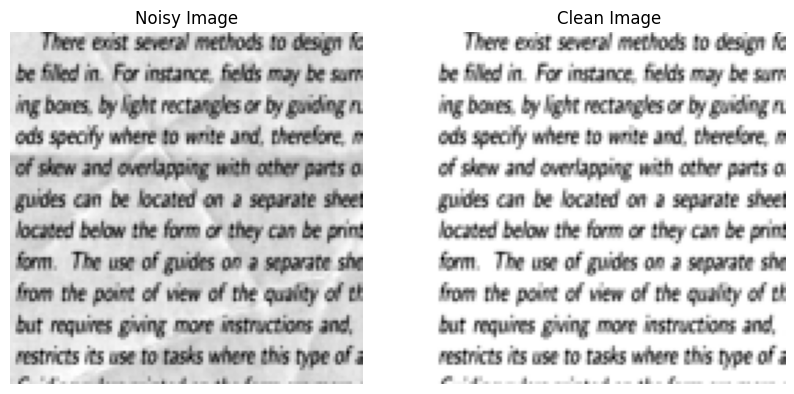

In [5]:
# lets see some images from the dataset
noisy_image, clean_image = dataset[0]
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.axis('off')
plt.title('Noisy Image')
plt.imshow(noisy_image.squeeze(), cmap='gray')
plt.subplot(1, 2, 2)
plt.axis('off')
plt.title('Clean Image')
plt.imshow(clean_image.squeeze(), cmap='gray')
plt.show()

In [6]:
# split data into train and validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset,
                                        [train_size, val_size], 
                                        generator=torch.Generator().manual_seed(42))

In [7]:
# create dataloader for train and validation
train_dataloader = DataLoader(train_dataset, batch_size=4, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=4, shuffle=False)

In [7]:
# define model

# Basic Convolution Block
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

# U-Net Model
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (Downsampling)
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512)

        # Decoder (Upsampling)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder + Skip Connections
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.final(d1)

In [8]:
# training loop
model = UNet().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    for noisy, clean in train_dataloader:
        noisy, clean = noisy.to(device), clean.to(device)

        optimizer.zero_grad()
        outputs = model(noisy)
        loss = criterion(outputs, clean)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * noisy.size(0)

    train_loss /= len(train_dataloader.dataset)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for noisy, clean in val_dataloader:
            noisy, clean = noisy.to(device), clean.to(device)
            outputs = model(noisy)
            loss = criterion(outputs, clean)
            val_loss += loss.item() * noisy.size(0)

    val_loss /= len(val_dataloader.dataset)

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')
    


Epoch [1/10], Train Loss: 0.4125, Val Loss: 0.0683
Epoch [2/10], Train Loss: 0.0399, Val Loss: 0.0337
Epoch [3/10], Train Loss: 0.0303, Val Loss: 0.0278
Epoch [4/10], Train Loss: 0.0237, Val Loss: 0.0201
Epoch [5/10], Train Loss: 0.0172, Val Loss: 0.0141
Epoch [6/10], Train Loss: 0.0123, Val Loss: 0.0102
Epoch [7/10], Train Loss: 0.0092, Val Loss: 0.0077
Epoch [8/10], Train Loss: 0.0069, Val Loss: 0.0068
Epoch [9/10], Train Loss: 0.0053, Val Loss: 0.0045
Epoch [10/10], Train Loss: 0.0044, Val Loss: 0.0043


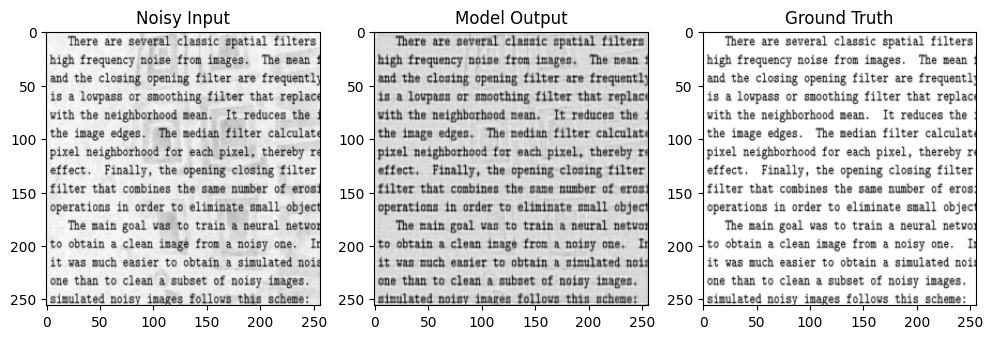

In [9]:
import matplotlib.pyplot as plt

model.eval()

noisy, clean = next(iter(val_dataloader))
noisy = noisy.to(device)
clean = clean.to(device)

with torch.no_grad():
    output = model(noisy)

# Move to CPU
noisy = noisy.cpu()
clean = clean.cpu()
output = output.cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Noisy Input")
plt.imshow(noisy[0][0], cmap='gray')

plt.subplot(1,3,2)
plt.title("Model Output")
plt.imshow(output[0][0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(clean[0][0], cmap='gray')

plt.show()

# Model 2

In [10]:
# define model

# Basic Convolution Block
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)

# U-Net Model
class UNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (Downsampling)
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512)

        # Decoder (Upsampling)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        # Output layer
        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder + Skip Connections
        d3 = self.up3(b)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return torch.sigmoid(self.final(d1))

In [11]:

mse_loss = nn.MSELoss()
l1_loss = nn.L1Loss()

def combined_loss(output, target):
    return 0.8 * mse_loss(output, target) + 0.2 * l1_loss(output, target)

In [12]:
model2 = UNet().to(device)

optimizer = torch.optim.Adam(model2.parameters(), lr=1e-4)

num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model2.train()
    train_loss = 0.0

    for noisy, clean in train_dataloader:
        noisy, clean = noisy.to(device), clean.to(device)

        optimizer.zero_grad()

        outputs = model2(noisy)
        loss = combined_loss(outputs, clean)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * noisy.size(0)

    train_loss /= len(train_dataloader.dataset)

    # Validation
    model2.eval()
    val_loss = 0.0

    with torch.no_grad():
        for noisy, clean in val_dataloader:
            noisy, clean = noisy.to(device), clean.to(device)

            outputs = model2(noisy)
            loss = combined_loss(outputs, clean)

            val_loss += loss.item() * noisy.size(0)

    val_loss /= len(val_dataloader.dataset)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model2.state_dict(), "best_model_v2.pth")
        print(" Best model saved!")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

 Best model saved!
Epoch [1/10] | Train: 0.1676 | Val: 0.0654
 Best model saved!
Epoch [2/10] | Train: 0.0632 | Val: 0.0654
Epoch [3/10] | Train: 0.0632 | Val: 0.0654
Epoch [4/10] | Train: 0.0632 | Val: 0.0654
Epoch [5/10] | Train: 0.0632 | Val: 0.0654
Epoch [6/10] | Train: 0.0632 | Val: 0.0654
Epoch [7/10] | Train: 0.0632 | Val: 0.0654
Epoch [8/10] | Train: 0.0632 | Val: 0.0654
Epoch [9/10] | Train: 0.0632 | Val: 0.0654
Epoch [10/10] | Train: 0.0632 | Val: 0.0654


In [13]:
model2.eval()

noisy, clean = next(iter(val_dataloader))
noisy = noisy.to(device)

with torch.no_grad():
    output = model2(noisy)

print("Min:", output.min().item())
print("Max:", output.max().item())

Min: 1.0
Max: 1.0


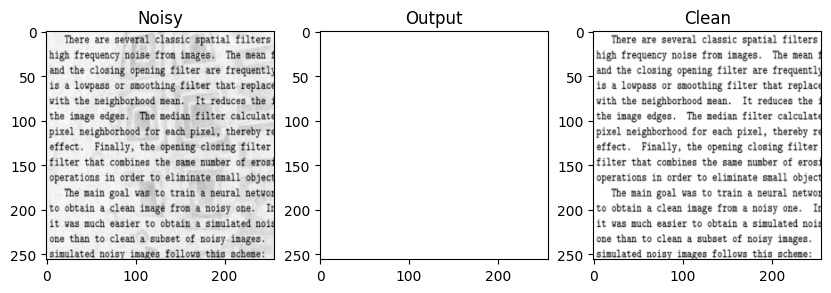

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,3,1)
plt.title("Noisy")
plt.imshow(noisy[0][0].cpu(), cmap='gray')

plt.subplot(1,3,2)
plt.title("Output")
plt.imshow(output[0][0].cpu(), cmap='gray', vmin=0, vmax=1)

plt.subplot(1,3,3)
plt.title("Clean")
plt.imshow(clean[0][0], cmap='gray')

plt.show()

# Attention U-Net Model

In [8]:
import torch
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()

        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1),
            nn.BatchNorm2d(F_int)
        )

        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )

        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)

        psi = self.relu(g1 + x1)
        psi = self.psi(psi)

        return x * psi

In [9]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

In [10]:
class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512)

        # Attention blocks
        self.att3 = AttentionBlock(256, 256, 128)
        self.att2 = AttentionBlock(128, 128, 64)
        self.att1 = AttentionBlock(64, 64, 32)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder + Attention
        d3 = self.up3(b)
        e3 = self.att3(d3, e3)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return x - self.final(d1)   # ❗ NO sigmoid

In [11]:
criterion = nn.MSELoss()
batch_size = 4
image_size = 128

model3 = AttentionUNet().to(device)

optimizer = torch.optim.Adam(model3.parameters(), lr=1e-4)

num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model3.train()
    train_loss = 0.0

    for noisy, clean in train_dataloader:
        noisy, clean = noisy.to(device), clean.to(device)

        optimizer.zero_grad()

        outputs = model3(noisy)
        loss = criterion(outputs, clean)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * noisy.size(0)

    train_loss /= len(train_dataloader.dataset)

    # Validation
    model3.eval()
    val_loss = 0.0

    with torch.no_grad():
        for noisy, clean in val_dataloader:
            noisy, clean = noisy.to(device), clean.to(device)

            outputs = model3(noisy)
            loss = criterion(outputs, clean)

            val_loss += loss.item() * noisy.size(0)

    val_loss /= len(val_dataloader.dataset)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model3.state_dict(), "best_model_v2.pth")
        print(" Best model saved!")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

 Best model saved!
Epoch [1/10] | Train: 0.0220 | Val: 0.0047
 Best model saved!
Epoch [2/10] | Train: 0.0038 | Val: 0.0028
 Best model saved!
Epoch [3/10] | Train: 0.0026 | Val: 0.0022
 Best model saved!
Epoch [4/10] | Train: 0.0022 | Val: 0.0019
 Best model saved!
Epoch [5/10] | Train: 0.0020 | Val: 0.0017
 Best model saved!
Epoch [6/10] | Train: 0.0018 | Val: 0.0015
 Best model saved!
Epoch [7/10] | Train: 0.0016 | Val: 0.0014
 Best model saved!
Epoch [8/10] | Train: 0.0016 | Val: 0.0014
 Best model saved!
Epoch [9/10] | Train: 0.0014 | Val: 0.0013
 Best model saved!
Epoch [10/10] | Train: 0.0013 | Val: 0.0012


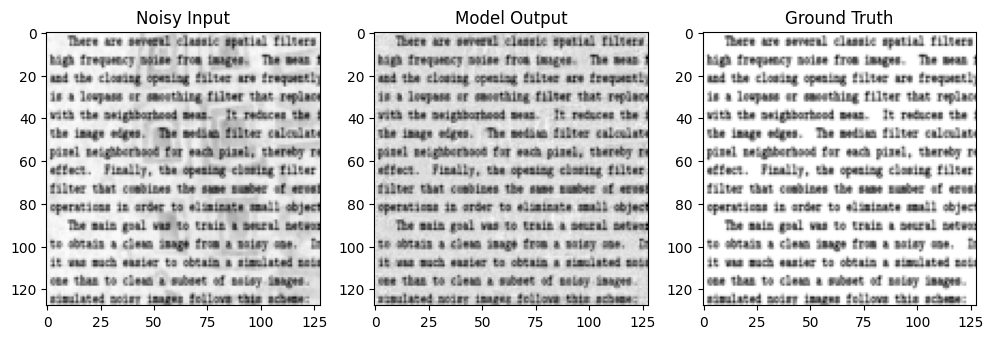

In [12]:
import matplotlib.pyplot as plt

model3.eval()

noisy, clean = next(iter(val_dataloader))
noisy = noisy.to(device)
clean = clean.to(device)

with torch.no_grad():
    output = model3(noisy)

# Move to CPU
noisy = noisy.cpu()
clean = clean.cpu()
output = output.cpu()

plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.title("Noisy Input")
plt.imshow(noisy[0][0], cmap='gray')

plt.subplot(1,3,2)
plt.title("Model Output")
plt.imshow(output[0][0], cmap='gray')

plt.subplot(1,3,3)
plt.title("Ground Truth")
plt.imshow(clean[0][0], cmap='gray')

plt.show()

# model 4

In [ ]:
class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder
        self.enc1 = ConvBlock(1, 64)
        self.enc2 = ConvBlock(64, 128)
        self.enc3 = ConvBlock(128, 256)

        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ConvBlock(256, 512)

        # Attention blocks
        self.att3 = AttentionBlock(256, 256, 128)
        self.att2 = AttentionBlock(128, 128, 64)
        self.att1 = AttentionBlock(64, 64, 32)

        # Decoder
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.dec3 = ConvBlock(512, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.dec2 = ConvBlock(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.dec1 = ConvBlock(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # Encoder
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))

        # Bottleneck
        b = self.bottleneck(self.pool(e3))

        # Decoder + Attention
        d3 = self.up3(b)
        e3 = self.att3(d3, e3)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        e2 = self.att2(d2, e2)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        e1 = self.att1(d1, e1)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return x +  self.final(d1)   # ❗ NO sigmoid

In [13]:
criterion = nn.MSELoss()
batch_size = 4
image_size = 128

model4 = AttentionUNet().to(device)

optimizer = torch.optim.Adam(model4.parameters(), lr=1e-4)

num_epochs = 10
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model4.train()
    train_loss = 0.0

    for noisy, clean in train_dataloader:
        noisy, clean = noisy.to(device), clean.to(device)

        optimizer.zero_grad()

        outputs = model4(noisy)
        loss = criterion(outputs, clean)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * noisy.size(0)

    train_loss /= len(train_dataloader.dataset)

    # Validation
    model4.eval()
    val_loss = 0.0

    with torch.no_grad():
        for noisy, clean in val_dataloader:
            noisy, clean = noisy.to(device), clean.to(device)

            outputs = model4(noisy)
            loss = criterion(outputs, clean)

            val_loss += loss.item() * noisy.size(0)

    val_loss /= len(val_dataloader.dataset)

    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model4.state_dict(), "best_model_v2.pth")
        print(" Best model saved!")

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

 Best model saved!
Epoch [1/10] | Train: 0.0464 | Val: 0.0158
 Best model saved!
Epoch [2/10] | Train: 0.0059 | Val: 0.0037
 Best model saved!
Epoch [3/10] | Train: 0.0035 | Val: 0.0030
 Best model saved!
Epoch [4/10] | Train: 0.0029 | Val: 0.0026
 Best model saved!
Epoch [5/10] | Train: 0.0025 | Val: 0.0022
 Best model saved!
Epoch [6/10] | Train: 0.0022 | Val: 0.0020
 Best model saved!
Epoch [7/10] | Train: 0.0020 | Val: 0.0019
 Best model saved!
Epoch [8/10] | Train: 0.0019 | Val: 0.0016
 Best model saved!
Epoch [9/10] | Train: 0.0017 | Val: 0.0015
 Best model saved!
Epoch [10/10] | Train: 0.0016 | Val: 0.0014


/home/mohsinkhan/Document-Denoising/venv/lib64/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


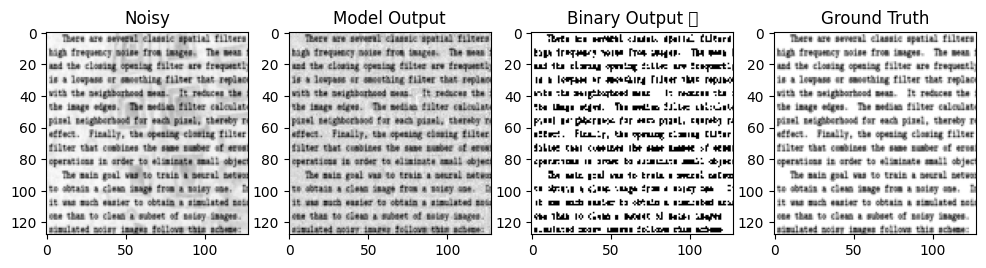

In [17]:
import matplotlib.pyplot as plt

model4.eval()

noisy, clean = next(iter(val_dataloader))
noisy = noisy.to(device)
clean = clean.to(device)

with torch.no_grad():
    output = model4(noisy)

# Convert to CPU tensors for visualization
noisy_cpu = noisy.cpu()
clean_cpu = clean.cpu()

output_np = output.cpu().numpy()

# Take first image
output_np = output_np[0][0]

# Normalize
output_np = (output_np - output_np.min()) / (output_np.max() - output_np.min())

# Threshold
binary = (output_np > 0.5).astype('uint8') * 255

plt.figure(figsize=(12,4))

plt.subplot(1,4,1)
plt.title("Noisy")
plt.imshow(noisy_cpu[0][0], cmap='gray')

plt.subplot(1,4,2)
plt.title("Model Output")
plt.imshow(output_np, cmap='gray')

plt.subplot(1,4,3)
plt.title("Binary Output 🔥")
plt.imshow(binary, cmap='gray')

plt.subplot(1,4,4)
plt.title("Ground Truth")
plt.imshow(clean_cpu[0][0], cmap='gray')

plt.show()